<table align="right"><tr>
     <td>  <h1> Practical Course Computer Based Chemistry (WS 25/26) </h1> </td>
</tr></table>

# Section 1. Univariate Statistics

## 1.1 Define python function

In [1]:
def hello_word(string_in='hello word!'):
    print(string_in)
    return ### can omit if no values are returned

In [2]:
hello_word()

hello word!


In [3]:
hello_word('hello word, here is Shuxia')

hello word, here is Shuxia


In [4]:
# hello_word('hello word, here's Shuxia')

In [5]:
hello_word('hello word, here\'s Shuxia')

hello word, here's Shuxia


In [6]:
hello_word("hello word, here's Shuxia")

hello word, here's Shuxia


## 2.2 Define python module
* multiple functions saved in one .py file named 'module_name.py'

In [7]:
import univar as uv

x = [1, -2, 4, 9, 3, 5]
res = uv.max_min(x)
print(res)

(9, -2)


In [8]:
v_max, v_min = uv.max_min(x)
print(v_max)
print(v_min)

9
-2


## 1.2 Distribution: theoretical and empirical

In [9]:
val = uv.check_distributions(n_sample=50, dist=['Uniform', 'Gaussian', 'Poisson', 'Binomial'][0])

expectation = 3.5
empirical mean = 3.84
variance = 2.9166666666666665
sample variance = 2.9744


In [10]:
val = uv.check_distributions(n_sample=5000, dist=['Uniform', 'Gaussian', 'Poisson', 'Binomial'][0])

expectation = 3.5
empirical mean = 3.5102
variance = 2.9166666666666665
sample variance = 2.90069596


In [11]:
val = uv.check_distributions(n_sample=50, dist=['Uniform', 'Gaussian', 'Poisson', 'Binomial'][1])

expectation = 0
empirical mean = 0.16766440554107692
variance = 1
sample variance = 0.7601637092340736


In [12]:
val = uv.check_distributions(n_sample=50, dist=['Uniform', 'Gaussian', 'Poisson', 'Binomial'][2])

expectation = 1
empirical mean = 1.14
variance = 1
sample variance = 1.4003999999999999


In [13]:
val = uv.check_distributions(n_sample=50, dist=['Uniform', 'Gaussian', 'Poisson', 'Binomial'][3])

expectation = 1.0
empirical mean = 0.94
variance = 0.99
sample variance = 0.9764000000000002


## 1.3 Statistical Test: parametric and nonparametric

In [14]:
from scipy import stats

### 1.3.1 Parametric test (t-test)

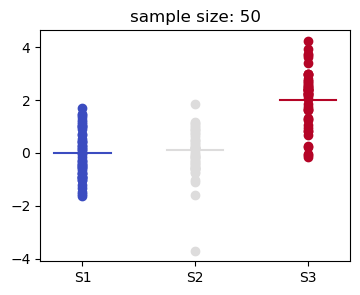

In [15]:
S_all = uv.gen_random(n_sample=50, list_mean=[0, 0.1, 2], list_var=[1, 1, 1])

In [16]:
### two-sample two-sided test (S1 vs S2)
t_stat, p_val = stats.ttest_ind(S_all[0], S_all[1], equal_var=True, alternative='two-sided')  
print('S1 differs to S2')
print("t-statistic = " + str(t_stat))  
print("p-value = " + str(p_val))

### two-sample one-sided test (S1 vs S3)
t_stat, p_val = stats.ttest_ind(S_all[0], S_all[2], equal_var=True, alternative='less')  
print('S1<S3')
print("t-statistic = " + str(t_stat))  
print("p-value = " + str(p_val))

### two-sample one-sided test (S1 vs S3)
t_stat, p_val = stats.ttest_ind(S_all[0], S_all[2], equal_var=True, alternative='greater')  
print('S1>S3')
print("t-statistic = " + str(t_stat))  
print("p-value = " + str(p_val))

S1 differs to S2
t-statistic = -0.35394120859168826
p-value = 0.72414330759876
S1<S3
t-statistic = -10.939280959093836
p-value = 5.607448798609236e-19
S1>S3
t-statistic = -10.939280959093836
p-value = 1.0


### 1.3.2 Non-Parametric test (t-test)

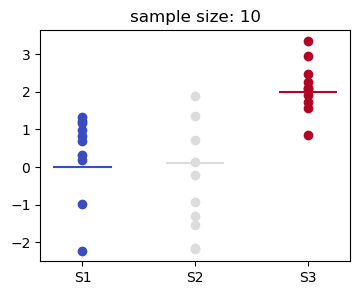

S1 differs to S2
t-statistic = 65.0
p-value = 0.27303633975118835
S1<S3
t-statistic = 4.0
p-value = 0.00029141997158963715
S1>S3
t-statistic = 4.0
p-value = 0.9997801806236867


In [17]:
S_all = uv.gen_random(n_sample=10, list_mean=[0, 0.1, 2], list_var=[1, 1, 1])

t_stat, p_val = stats.mannwhitneyu(S_all[0], S_all[1], alternative='two-sided')
print('S1 differs to S2')
print("t-statistic = " + str(t_stat))  
print("p-value = " + str(p_val))

t_stat, p_val = stats.mannwhitneyu(S_all[0], S_all[2], alternative='less')
print('S1<S3')
print("t-statistic = " + str(t_stat))  
print("p-value = " + str(p_val))

t_stat, p_val = stats.mannwhitneyu(S_all[0], S_all[2], alternative='greater')
print('S1>S3')
print("t-statistic = " + str(t_stat))  
print("p-value = " + str(p_val))

## 1.4 Optimization: peak fitting

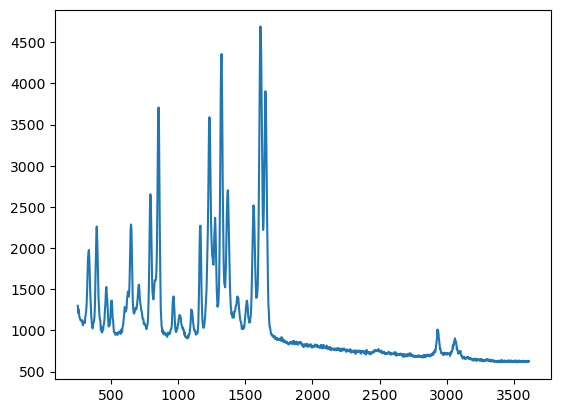

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
### load data and plot
data = pd.read_table('4aap_data.txt', sep=' ', header=None)
wn = data[0].values
spec = data[1].values

plt.plot(wn, spec)

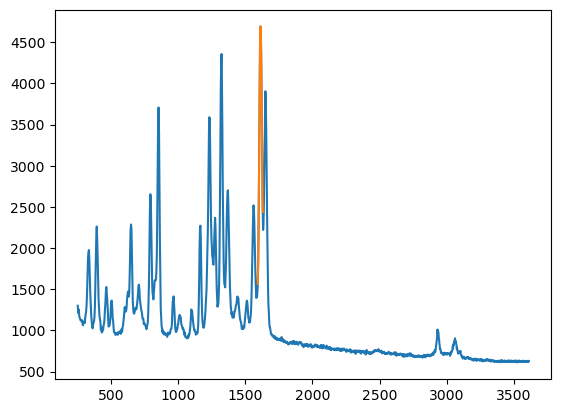

In [19]:
### find the most intensive peak
ix_max = np.argmax(spec)
peak_max = wn[ix_max]
### mark maximal peak:
plt.plot(wn, spec)
plt.plot(wn[(ix_max-7):(ix_max+7)], spec[(ix_max-7):(ix_max+7)])

position: 1613.66
intensity: 4659.21
width: 20.45


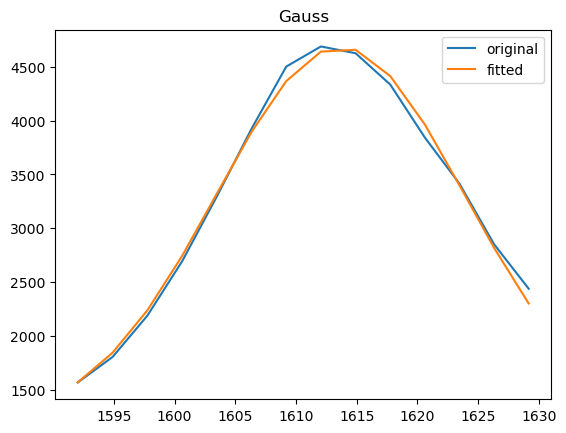

In [20]:
import scipy.optimize as spo

x = wn[(ix_max-7):(ix_max+7)]
y = spec[(ix_max-7):(ix_max+7)]

### initialization
O_0 = np.min(y)
b_0 = peak_max
c_0 = 5
A_0 = np.max(y) - np.min(y)
p0 = [O_0, A_0, b_0, c_0]  ### initial guess

### fit peak in to Gaussian:
popt, _ = spo.curve_fit(uv.gauss_func, x, y, p0=p0, method='trf', bounds=(0, np.inf))
result = {'O': popt[0], 'A': popt[1], 'b': popt[2], 'c': popt[3]} 

fitted = uv.gauss_func(x, result['O'], result['A'], result['b'], result['c'])

print('position: '+ str(np.round(result['b'],2)))
print('intensity: '+ str(np.round(np.max(fitted),2)))
print('width: '+str(np.round(2*result['c'],2)))

### plot fitting
plt.plot(x, y, label='original')
plt.plot(x, fitted, label='fitted')
plt.title('Gauss')
plt.legend()

position: 1613.65
intensity: 4703.39
width: 30.56


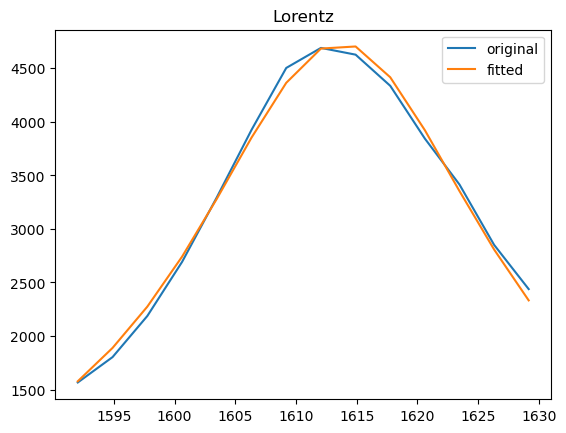

In [21]:
### fit peak in to Lorenz:
popt, _ = spo.curve_fit(uv.lorentz_func, x, y, p0=p0, method='trf', bounds=(0, np.inf))
result = {'O': popt[0], 'A': popt[1], 'b': popt[2], 'c': popt[3]} 

fitted = uv.lorentz_func(x, result['O'], result['A'], result['b'], result['c'])

print('position: '+ str(np.round(result['b'],2)))
print('intensity: '+ str(np.round(np.max(fitted),2)))
print('width: '+str(np.round(2*result['c'],2)))

### plot fitting
plt.plot(x, y, label='original')
plt.plot(x, fitted, label='fitted')
plt.title('Lorentz')
plt.legend()